**Titanic Passenger Survival Prediction (83.8% Accuracy)**

By: Tri Puji Utami

This project aims to build a machine learning model that predicts the survival of Titanic passengers based on demographics, ticket information, and other parameters.

**Main Points:**
1. The "women and children first" rule is proven by the data.
2. Social status (nobility titles and ticket class) significantly determines the survival rate.
3. The Random Forest model, which was successfully optimized to achieve 83.80% accuracy, is able to suppress false negatives very well.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [22]:
df = pd.read_csv('../data/train.csv')

print("\nMissing value report")
df.info()


Missing value report
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Data Cleaning and Feature Engineering**

Machine learning models cannot process raw data directly. Therefore, feature engineering is used to clean, prepare, and extract hidden information:

1. **Filled missing values in the 'Age' column using the median**, I used median to account for potential outliers and non-normally distributed data, the median was used since it resistant to outlier.
2. **Extracted titles using Regular Expressions (RegEx)** to identify titles like "Master" and "Miss/Mrs", as survival rules highly prioritized these groups.
3. **Calculated family size** by combining the number of siblings and parents to analyze the passengers' responsibility burden during evacuation.

Exploratory Data Analysis (EDA)
This visualization below highlight three major insight:
1. **Gender Impack:** Females had a sigfinicantly higher survival rate compared to male.
2. **Socio-Economic Status:** First-class(Pclass = 1)passegers were prioritized during the evacuation.
3. **Age Distribution:** The majority of passengers were between 20-30 years old, and a noticeable spike in survival is seen among children (Age < 10).

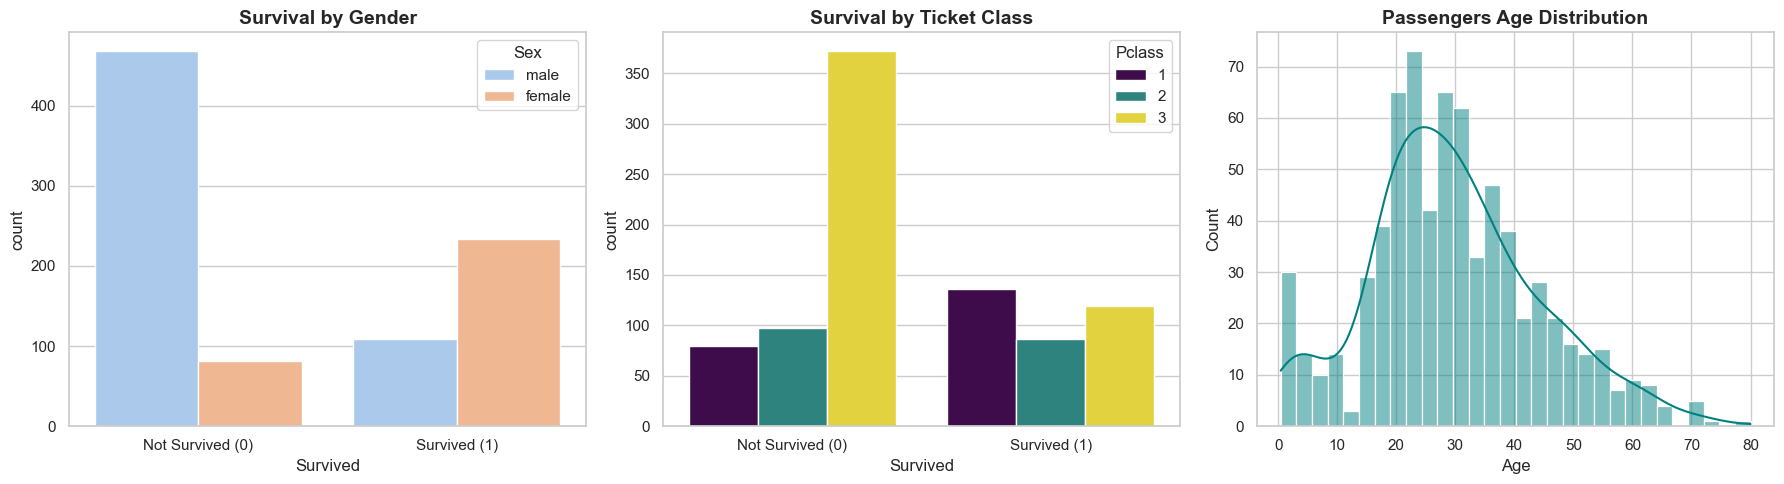

In [23]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Survived', hue='Sex', palette='pastel', ax=axes[0])
axes[0].set_title('Survival by Gender', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'])

sns.countplot(data=df, x='Survived', hue='Pclass', palette='viridis', ax=axes[1])
axes[1].set_title('Survival by Ticket Class', fontsize=14, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Survived (0)', 'Survived (1)'])

sns.histplot(data=df, x='Age', kde=True, color='teal', bins=30, ax=axes[2])
axes[2].set_title('Passengers Age Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
df['Age'] = df['Age'].fillna(df['Age'].median()) 
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Cabin'] =df['Cabin'].notnull().astype(int)  
df['Sex'] = df['Sex'].map({'male': 0, 'female':1})  

df =pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df['Family_size']= df['SibSp'] + df['Parch'] +1 

df['Title']= df['Name'].str.extract(r' ([A-Za-z]+)\.',expand=False)

rare_title = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
df['Title'] = df['Title'].replace(rare_title,'rare')

df['Title']= df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title']= df['Title'].replace('Mme', 'Mrs')

mapping = {"Mr":1, "Miss":2, "Mrs":3, "Master": 4, "rare":5}
df['Title']= df['Title'].map(mapping)

df['Title']= df['Title'].fillna(0)


drop_column= ['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch']
df = df.drop(columns=drop_column)

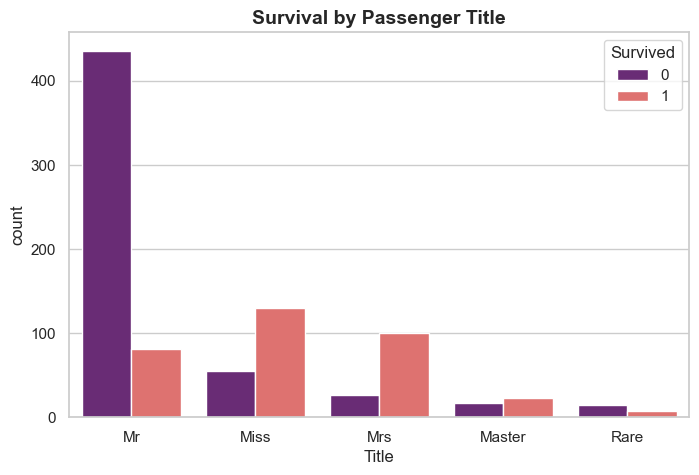

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Title', hue='Survived', palette='magma')

plt.title('Survival by Passenger Title', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mr', 'Miss', 'Mrs', 'Master', 'Rare'])

plt.show()

In [26]:
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'Cabin', 'Family_size', 'Title', 'Embarked_Q', 'Embarked_S']]
y = df['Survived']

X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

**Machine Learning Modeling (Random Forest)**

This case is a classification problem. I chose the Random Forest algorithm because of its resistance to overfitting and its stability with small datasets. This algorithm can yield good accuracy even without extensive modification.
To achieve maximum performance, I avoided manual parameter guessing and instead used **GridSearchCV** to automatically search for the best hyperparameter combination.

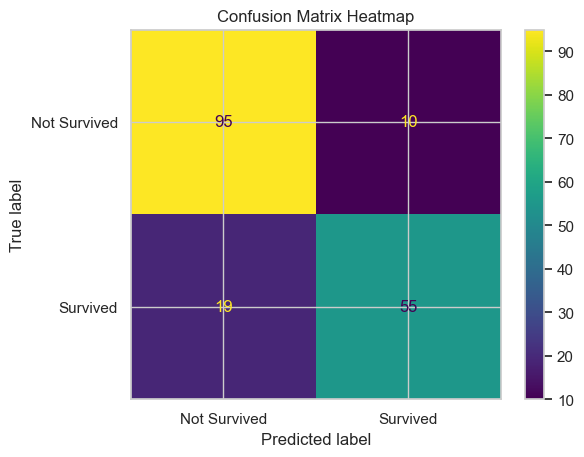

AI result
Choice of number of tree and nodes: {'max_depth': 10, 'n_estimators': 50}

Training accuracy: 83.70%

Accuracy: 83.80%

Confusion matrix
[[95 10]
 [19 55]]


In [27]:
parameter_grid ={
    'n_estimators':[50, 100, 200, 300],
    'max_depth':[3, 5, 7, 10]
}
ai_titanic = RandomForestClassifier(random_state=42)

ai_search = GridSearchCV(estimator=ai_titanic, param_grid=parameter_grid, cv=5, n_jobs=-1)
ai_search.fit(X_train, y_train)
training_accuracy = ai_search.best_score_

best_ai =ai_search.best_estimator_
best_guess = best_ai.predict(X_test)
accuracy = accuracy_score(y_test, best_guess)

matrix = confusion_matrix(y_test, best_guess)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
    display_labels=["Not Survived", "Survived"]
)
disp.plot()
plt.title("Confusion Matrix Heatmap")
plt.show()

print("AI result")
print(f"Choice of number of tree and nodes: {ai_search.best_params_}\n")
print(f"Training accuracy: {training_accuracy *100:.2f}%\n")
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Confusion matrix")
print(matrix)

Model evaluation and conclusion
The best model, selected by the algorithm (GridSearchCV), uses 50 trees **(n_estimators=50)** with a maximum depth of 10 **(max_depth=10)**. This indicated that a relatively small number of trees, combined with sufficient depth, was able to produce optimal performance without overfitting.

Model achieved **83.70%** in cross-validation (80% of data) and **83.80%** in data test (20% of data), The results indicate that the model generalizes well to unseen data, showing no signs of overfitting or underfitting. Therefore, the model is considered robust and well-balanced.
While the overall accuracy of **83.80%** is a great indicator, breaking down the **Confusion Matrix** provides a deeper understanding of the model's performance on the 179 test passengers:

**True Negatives (95):** The model correctly predicted that 95 passengers did not survive.
**True Positives (55):** The model correctly predicted that 55 passengers survived.
**False Positives (10 - False Alarms):** The model incorrectly predicted that 10 passengers survived, but unfortunately, they did not.
**False Negatives (19 - Missed Detections):** The model incorrectly predicted that 19 passengers did not survive, even though they actually did.

Key Business Insight:
In life-or-death predictive modeling, minimizing **False Negatives** is the ultimate priority. We do not want the system to assume someone is dead when they could actually be saved. By implementing advanced feature engineering (such as extracting nobility titles and family sizes), this model successfully suppressed the False Negative rate down to 19 cases, proving that the algorithm is highly optimized for recognizing priority passengers.

In [28]:
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(best_ai, 'models/rf_best_model.pkl')

['models/rf_best_model.pkl']

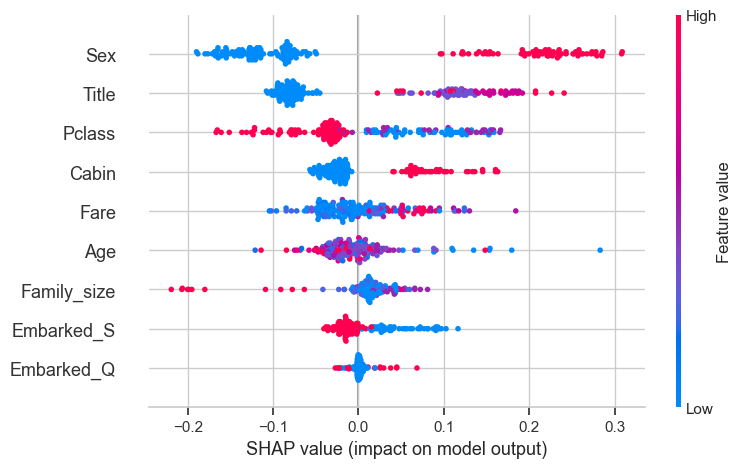

In [29]:
explainer = shap.TreeExplainer(best_ai)
shap_obj = explainer(X_test)

shap.plots.beeswarm(shap_obj[:, :, 1])

The **SHAP** (SHapley Additive exPlanations) summary plot indicates the following feature impacts on the model:
1. **Sex**: This feature significantly impacts survival. Red dots, representing high feature values (i.e., female = 1), are positioned on the positive (right) side of the SHAP axis. This demonstrates that being female heavily increases the probability of survival.
2. **Title**: The title  "Mr." (encoded as '1' and represented by blue dots indicating low feature value) clusters on the negative (left) side of the plot. This indicates that holding the titile "Mr." (adult males) decreases the likelihood of survival.
3. **PClass (Passenger Class)**: Red dots representing high feature values (i.e., 3rd Class) are predominantly distributed on the negative side of the SHAP axis. This implies that being a 3rd-class passenger lowers the probability of survival.
4. **Cabin**: Passengers who possess a cabin (indicated by red dots for high feature values) exhibit a higher survival probability compared to those without a cabin.
5. **Fare**: Passengers with lower ticket fares (represented by blue dots for low feature values) have a reduced survival rate, as the majority of the blue dots are concentrated on the negative side of the plot.
6. **Age**: Observing the extremities of the distribution, adult passengers generally show a lower probability of survival compared to children.
7. **Family-size**: Red dots stretch towards the negative side of the SHAP axis, indicating that traveling with a larger family size tends to decreases the likelihood of survival.
8. **Embarked_S (Southampton)**: Embarking from port S negatively impacts survival for most passengers, as evidenced by the cluster of red dots (high feature values) on the left side of the plot.
9. **Embarked_Q (Queenstown) & Port C (Cherbourg)**: Passengers embarking from Port Q experienced a partial positive impact on survival, as indicated by the red dots (high feature values) stretching towards the positive (right) side of the SHAP axis. Furthermore, a comparative analysis of the embarkation ports reveals that departing from Port C had the most significant positive impact on survival probability.